# Machine Learning and Deep Learning for Coastal Engineering

## Seminar Overview

This session introduces:
- Machine Learning fundamentals
- Deep Learning concepts
- Applications in coastal engineering

## Key questions
- How can we use data-driven models in coastal systems?
- What are the advantages over traditional approaches?

## Types of Data in Coastal Engineering

- **Time series (waves, tides)**
- Spatial data (bathymetry, shoreline)
- Spatio-temporal data (wave fields, currents)

## Study Area

The study area is located in the southeastern **Bay of Biscay**, focusing on the **Basque Country coastline** and the surroundings of the **Bilbao harbor and the Nervión Estuary** (approx. 43°20′ N, 3°01′ W).

This North Atlantic region features a relatively **narrow continental shelf** (7–20 km wide) and a **rugged coastline** composed of rocky cliffs and small pocket beaches.

The coastline orientation (N–NW) and the absence of land in that direction provide an **almost unlimited fetch**, exposing the region to energetic waves generated by North Atlantic storms.

![Study Area](../figures/jmse-14-00646-g001.png)

**Figure 1.** Location of the study area in the Bay of Biscay, including the offshore wave buoys used in this study.

## Time Series

A time series is a sequence of observations indexed in time.

Example:
Hs(t) = wave height at time t

Key properties:
- temporal dependence
- seasonality
- trends

**CARGAMOS LOS DATOS**

C:\Users\user\AppData\Local\Temp\ipykernel_31440\2874400534.py:6: DtypeWarning: Columns (1,2,3,4,5,6,7,8,9,10,11,12,13) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("../data/datos_PE_costera_II.csv", sep=";")


['Fecha', 'Hs', 'Altura signif. de cruce por cero (H1/3)(m)', 'Periodo Medio(s)', 'Periodo Medio Tm02(s)', 'Periodo de Pico(s)', 'Altura Máxima del Oleaje(m)', 'Periodo de la Ola Maxima(s)', 'Canal de obtencion de los datos', 'Direcc. Media de Proced.(0=N,90=E)', 'Direccion Media en el Pico Espectral(0=N,90=E)', 'Dispersión angular en toda la banda resuelta(grados)', 'Dispersión angular en el pico de energía espectral(grados)', 'Canal de obtencion de los datos.1']


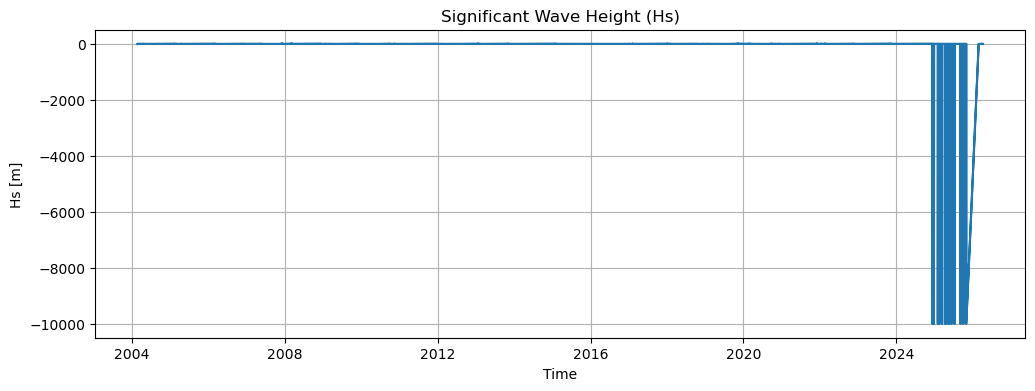

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("../data/datos_PE_costera_II.csv", sep=";")

# Preview
df.head()
print(df.columns.tolist())
# Convert date
df["Fecha"] = pd.to_datetime(df["Fecha"], format="%Y %m %d %H", errors="coerce")
df["Hs"] = pd.to_numeric(df["Hs"], errors="coerce")
# Set index
df.set_index("Fecha", inplace=True)
plt.figure(figsize=(12,4))
plt.plot(df["Hs"])
plt.title("Significant Wave Height (Hs)")
plt.ylabel("Hs [m]")
plt.xlabel("Time")
plt.grid()
plt.show()

## Data Quality Issues

When working with real coastal datasets, data quality problems are very common.

In this dataset, we observe:

- Presence of extreme values such as **-9999**
- These values do not represent physical measurements
- They are used as **missing data flags (NaN equivalents)**

### Why is this a problem?

- These values distort visualization
- They can completely break machine learning models
- They must be removed or properly handled before analysis

### Cleaning step

We replace invalid values (-9999) with NaN and remove them from the analysis.

After cleaning:
- The time series becomes physically meaningful
- However, **temporal gaps appear in the data**

These gaps are exactly the type of problem we aim to solve using Deep Learning methods such as LSTM.

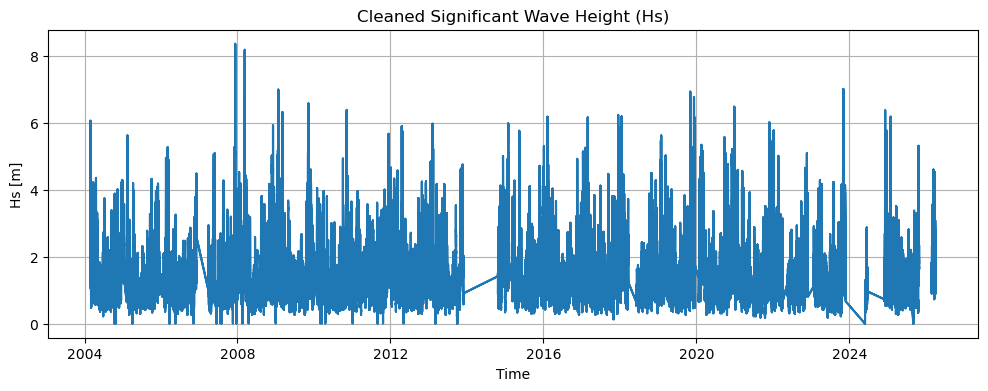

In [2]:
# Replace invalid values (-9999) with NaN
df["Hs"] = df["Hs"].replace(-9999.9, np.nan)

# Remove NaNs
df["Hs_clean"] = df["Hs"].replace(-9999.9, np.nan)

plt.figure(figsize=(12,4))
plt.plot(df["Hs"])
plt.title("Cleaned Significant Wave Height (Hs)")
plt.ylabel("Hs [m]")
plt.xlabel("Time")
plt.grid()
plt.show()

## Exploratory Data Analysis (EDA)

Before applying any machine learning model, it is essential to understand the data.

In this section, we will:
- analyze the distribution of the variables
- explore temporal patterns
- identify anomalies and gaps
- understand the structure of the dataset

This step is critical in any real data science workflow.

In [3]:
df["Hs_clean"].describe()


count    309708.000000
mean          1.419349
std           0.832626
min           0.000000
25%           0.830000
50%           1.200000
75%           1.780000
max           8.370000
Name: Hs_clean, dtype: float64

What values do we have?

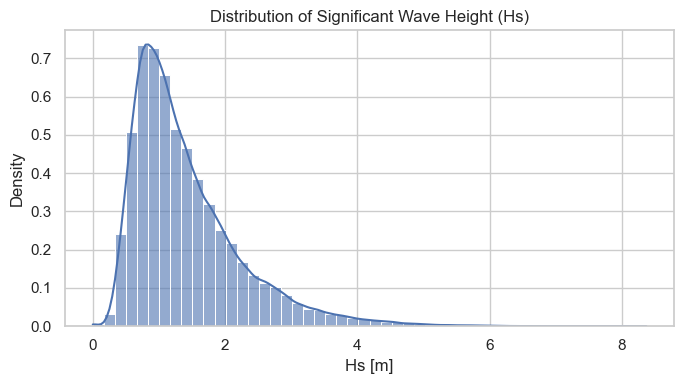

In [4]:
import seaborn as sns
# Set style
sns.set(style="whitegrid")

plt.figure(figsize=(7,4))

sns.histplot(
    df["Hs_clean"].dropna(),
    bins=50,
    kde=True,
    stat="density",
    alpha=0.6
)

plt.title("Distribution of Significant Wave Height (Hs)", fontsize=12)
plt.xlabel("Hs [m]")
plt.ylabel("Density")

plt.tight_layout()
plt.show()

## Temporal Analysis

The distribution of wave height is useful, but it does not show how the system evolves in time.

In coastal engineering, temporal structure is essential:
- storms appear as peaks
- calm periods alternate with energetic conditions
- missing data may occur in blocks rather than randomly

For this reason, we now inspect the time series in detail.

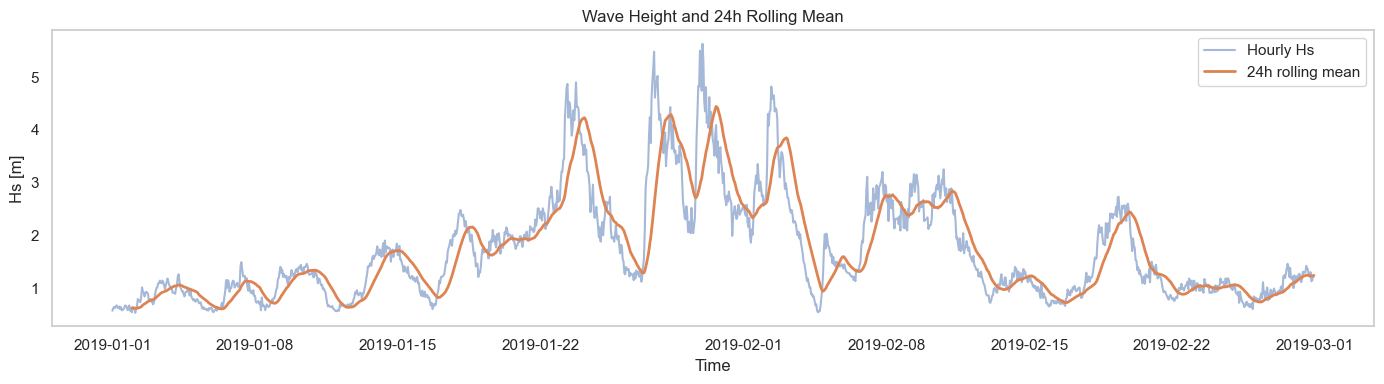

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../data/datos_PE_costera_II.csv", sep=";", low_memory=False)

# Clean likely junk
df.columns = df.columns.str.strip()
df["Fecha"] = df["Fecha"].astype(str).str.strip()
df["Hs"] = df["Hs"].astype(str).str.strip()

df = df[
    (df["Fecha"] != "Fecha") &
    (df["Fecha"] != "=======") &
    (df["Hs"] != "Hs")
].copy()

# Parse types
df["Fecha"] = pd.to_datetime(df["Fecha"], format="%Y %m %d %H", errors="coerce")
df["Hs_clean"] = pd.to_numeric(df["Hs"], errors="coerce")

# Drop invalid rows
df = df.dropna(subset=["Fecha", "Hs_clean"]).copy()

# Set index and sort
df = df.set_index("Fecha").sort_index()

# Optional: remove duplicate timestamps
df = df[~df.index.duplicated(keep="first")]

# Zoom
df_zoom = df.loc["2019-01":"2019-02", ["Hs_clean"]].copy()
df_zoom["Hs_rolling"] = df_zoom["Hs_clean"].rolling(window=24).mean()

# Plot
plt.figure(figsize=(14, 4))
plt.plot(df_zoom.index, df_zoom["Hs_clean"], label="Hourly Hs", alpha=0.5)
plt.plot(df_zoom.index, df_zoom["Hs_rolling"], label="24h rolling mean", linewidth=2)

plt.title("Wave Height and 24h Rolling Mean")
plt.xlabel("Time")
plt.ylabel("Hs [m]")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

In [6]:
n_total = df["Hs_clean"].shape[0]
n_missing = df["Hs_clean"].isna().sum()
missing_pct = 100 * n_missing / n_total

print(f"Total samples: {n_total}")
print(f"Missing samples: {n_missing}")
print(f"Missing percentage: {missing_pct:.2f}%")

Total samples: 154875
Missing samples: 0
Missing percentage: 0.00%


Not all gaps are the same. Some are short and others are very long. This greatly influences the difficulty of the problem.

## Problem Formulation

From the exploratory analysis, we observe that:

- the wave record has a clear temporal structure
- missing values are present and may occur in contiguous blocks
- the reconstruction problem is therefore not trivial

A suitable model should:
- exploit temporal dependence
- learn from previous observations
- reconstruct missing values in a physically consistent way

This motivates the use of recurrent neural networks, and in particular, LSTM models.

> Given a signal with a missing segment, estimate the missing values using temporal information from the surrounding data.

### Why is this challenging?
This is not a simple interpolation task because:
- the signal is nonlinear
- there may be energetic events and rapid changes
- temporal dependence is important

This motivates the use of sequence models such as **LSTM**.

## Train, Validation and Test Strategy

In this reconstruction problem, the artificially removed segment is used as the **test set**.

We define:

- **Training set**: temporal sequences before the gap
- **Validation set**: temporal sequences after the gap
- **Test set**: the missing segment itself

This strategy avoids mixing the target reconstruction interval with the data used for model fitting.

In [33]:
series = df_zoom["Hs_clean"].copy()

print("Total length:", len(series))
series.head()
# Temporal split
n = len(series)

train_end = int(n * 0.85)
val_end = int(n * 0.97)

train_series = series.iloc[:train_end].copy()
val_series = series.iloc[train_end:val_end].copy()
test_series = series.iloc[val_end:].copy()

print("Train length:", len(train_series))
print("Validation length:", len(val_series))
print("Test length:", len(test_series))

# Entire test period treated as missing
test_series_gap = test_series.copy()
test_series_gap[:] = np.nan

Total length: 1409
Train length: 1197
Validation length: 169
Test length: 43


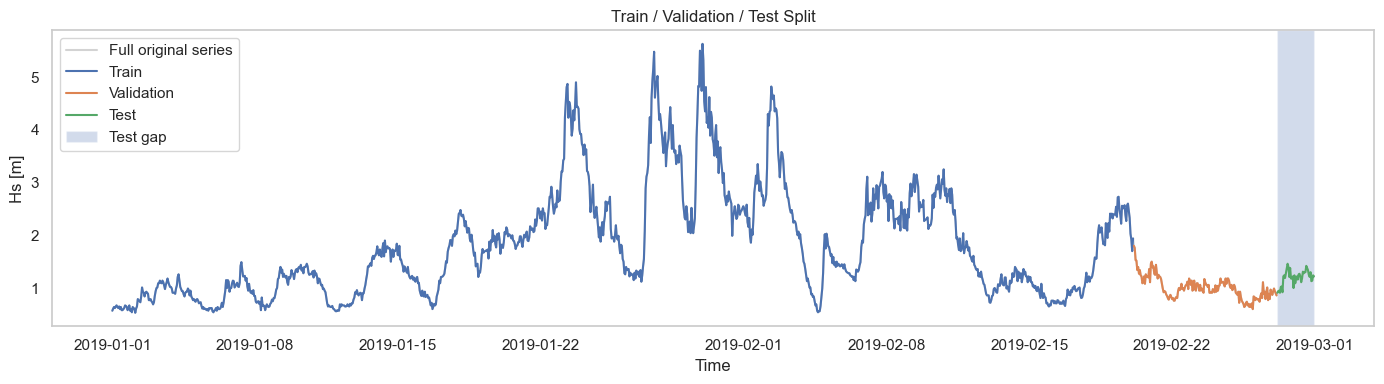

In [34]:
plt.figure(figsize=(14,4))

plt.plot(series.index, series.values, color="lightgray", label="Full original series")
plt.plot(train_series.index, train_series.values, label="Train")
plt.plot(val_series.index, val_series.values, label="Validation")
plt.plot(test_series.index, test_series.values, label="Test")

plt.axvspan(
    test_series.index[0],
    test_series.index[-1],
    alpha=0.25,
    label="Test gap"
)

plt.title("Train / Validation / Test Split")
plt.ylabel("Hs [m]")
plt.xlabel("Time")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

### GAP Reconstruction using LSTM

In this section, we simulate a real-world coastal engineering problem: missing data in time series. We artificially remove a segment of the wave height signal and use a Long Short-Term Memory (LSTM) neural network to reconstruct it.

The LSTM model learns temporal dependencies from the available data and predicts missing values based on past observations

In [35]:
import numpy as np
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

train_scaled = scaler.fit_transform(train_series.values.reshape(-1, 1))
val_scaled = scaler.transform(val_series.values.reshape(-1, 1))

In [36]:
def create_sequences(data, window_size=180):
    X, y = [], []
    for i in range(len(data) - window_size):
        X.append(data[i:i+window_size])
        y.append(data[i+window_size])
    return np.array(X), np.array(y)

window_size = 24

X_train, y_train = create_sequences(train_scaled, window_size)
X_val, y_val = create_sequences(val_scaled, window_size)

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_val shape:", X_val.shape)
print("y_val shape:", y_val.shape)

X_train shape: (1173, 24, 1)
y_train shape: (1173, 1)
X_val shape: (145, 24, 1)
y_val shape: (145, 1)


In [37]:
X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_val = X_val.reshape((X_val.shape[0], X_val.shape[1], 1))

In [38]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

model = Sequential([
    LSTM(32, input_shape=(window_size, 1)),
    Dense(1)
])

model.compile(optimizer="adam", loss="mse")
model.summary()

C:\Users\user\anaconda3\envs\coastal-ml-seminar\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                        │ (None, 32)                  │           4,352 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 4,385 (17.13 KB)

 Trainable params: 4,385 (17.13 KB)

 Non-trainable params: 0 (0.00 B)

In [39]:
history = model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=16,
    validation_data=(X_val, y_val),
    verbose=1
)

Epoch 1/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0166 - val_loss: 0.0011
Epoch 2/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0051 - val_loss: 7.0793e-04
Epoch 3/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0042 - val_loss: 6.0145e-04
Epoch 4/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0033 - val_loss: 4.5286e-04
Epoch 5/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0028 - val_loss: 4.1812e-04
Epoch 6/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0026 - val_loss: 2.7748e-04
Epoch 7/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0024 - val_loss: 2.7117e-04
Epoch 8/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0023 - val_loss: 8.1139e-04
Epoch 9/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0021 - val_loss: 5.3434e-04
Epoch 10/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0020 - val_loss: 2.7761e-04
Epoch 11/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0019 - val_loss: 3.0594e-04
Epoch 12/20
74/74 ━━━━━━━━━━━━━━━━

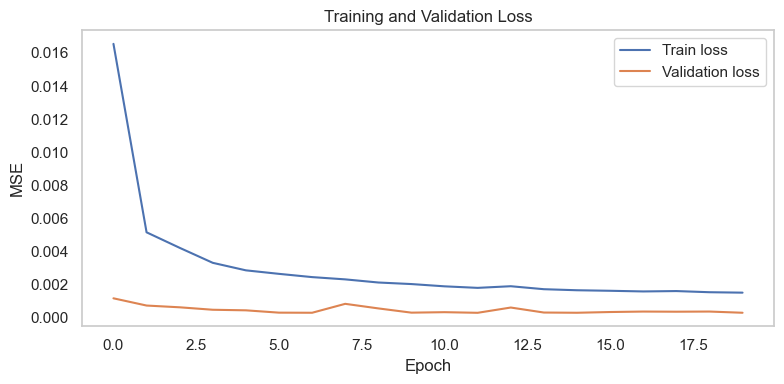

In [40]:
plt.figure(figsize=(8,4))
plt.plot(history.history["loss"], label="Train loss")
plt.plot(history.history["val_loss"], label="Validation loss")

plt.title("Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

In [41]:
# Combine validation context + empty test gap
full_context = pd.concat([val_series.copy(), test_series_gap.copy()])
full_reconstructed = full_context.copy()

test_start_idx = len(val_series)
test_end_idx = len(full_context)

for i in range(test_start_idx, test_end_idx):
    input_window = full_reconstructed.iloc[i-window_size:i].values.reshape(-1, 1)
    
    input_window_scaled = scaler.transform(input_window)
    input_window_scaled = input_window_scaled.reshape((1, window_size, 1))
    
    pred_scaled = model.predict(input_window_scaled, verbose=0)
    pred = scaler.inverse_transform(pred_scaled)[0, 0]
    
    full_reconstructed.iloc[i] = pred

# Keep reconstructed test only
test_reconstructed = full_reconstructed.iloc[test_start_idx:].copy()

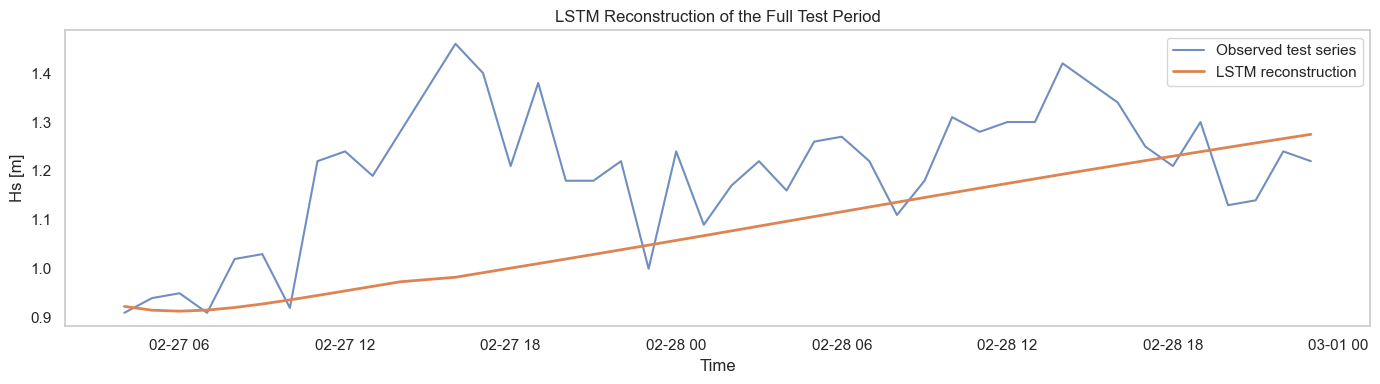

In [42]:
plt.figure(figsize=(14,4))

plt.plot(test_series.index, test_series.values, label="Observed test series", alpha=0.8)
plt.plot(test_reconstructed.index, test_reconstructed.values, label="LSTM reconstruction", linewidth=2)

plt.title("LSTM Reconstruction of the Full Test Period")
plt.ylabel("Hs [m]")
plt.xlabel("Time")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

In [32]:
from sklearn.metrics import mean_squared_error, r2_score

y_true = test_series.values
y_pred = test_reconstructed.values

rmse = np.sqrt(mean_squared_error(y_true, y_pred))
r2 = r2_score(y_true, y_pred)
mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
bias = np.mean(y_pred - y_true)

print(f"RMSE: {rmse:.3f}")
print(f"R2: {r2:.3f}")
print(f"MAPE: {mape:.2f}%")
print(f"Bias: {bias:.3f}")

RMSE: 0.164
R2: 0.318
MAPE: 12.00%
Bias: -0.118


## Model Evaluation

To assess the performance of the LSTM model in reconstructing the missing segment, we use several standard evaluation metrics:

### Root Mean Squared Error (RMSE)

Measures the average magnitude of the error:

$$
RMSE = \sqrt{\frac{1}{N} \sum_{i=1}^{N} (y_i - \hat{y}_i)^2}
$$

---

### Coefficient of Determination ($R^2$)

Indicates how well predictions match observations:

$$
R^2 = 1 - \frac{\sum (y_i - \hat{y}_i)^2}{\sum (y_i - \bar{y})^2}
$$

---

### Mean Absolute Percentage Error (MAPE)

Measures relative error:

$$
MAPE = \frac{100}{N} \sum \left| \frac{y_i - \hat{y}_i}{y_i} \right|
$$

---

### Bias

Indicates systematic over/underestimation:

$$
Bias = \frac{1}{N} \sum (\hat{y}_i - y_i)
$$

---

These metrics are computed **only on the artificially removed gap**, which simulates missing data reconstruction.


In [ ]:
import numpy as np
from sklearn.metrics import mean_squared_error, r2_score

# Extraer zona del gap
y_true = series.iloc[gap_start:gap_start+gap_len].values
y_pred = series_pred.iloc[gap_start:gap_start+gap_len].values

# Eliminar posibles NaNs
mask = ~np.isnan(y_true) & ~np.isnan(y_pred)
y_true = y_true[mask]
y_pred = y_pred[mask]

# RMSE
rmse = np.sqrt(mean_squared_error(y_true, y_pred))

# R2
r2 = r2_score(y_true, y_pred)

# MAPE
mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100

# Bias
bias = np.mean(y_pred - y_true)

print(f"RMSE: {rmse:.3f}")
print(f"R2: {r2:.3f}")
print(f"MAPE: {mape:.2f} %")
print(f"Bias: {bias:.3f}")
plt.figure(figsize=(6,6))

plt.scatter(y_true, y_pred, alpha=0.6)

# Línea perfecta
min_val = min(y_true.min(), y_pred.min())
max_val = max(y_true.max(), y_pred.max())

plt.plot([min_val, max_val], [min_val, max_val], 'r--')

plt.xlabel("Observed Hs [m]")
plt.ylabel("Predicted Hs [m]")
plt.title("Predicted vs Observed (Gap Only)")
plt.grid()

plt.tight_layout()
plt.show()